
<h1 style="text-align: center;">CIÊNCIA DE DADOS</h1>
<h1 style="text-align: center;">Roteiro de Atividade Prática</h1>
<br>
<br>

Nome: ______________________________________________________________________________________      

Turma: ______________


**Componente:** Análise Exploratória de Dados e Inteligência de Negócios
<br>
**Unidade Curricular:** Análise Exploratória de Dados
<br>
**Tema da Semana:** Análise de Grupos: Clusterização, segmentação de dados
<br>


# Aula 4: Exercícios de Fixação: Análise de Grupos

## Tarefa
- Execute o código abaixo.

- Se as bibliotecas não tiverem instaladas, instale-as.

- Acompanhe as instruções.

- Preencha o código onde está #TO DO

- Responda as perguntas e conclua a atividade


# Aula Prática de Clusterização com K-Means, DBSCAN e Agrupamento Hierárquico

## Introdução

Olá, pessoal! Nesta aula, vamos explorar o mundo da **clusterização**, uma técnica de aprendizado de máquina que nos permite agrupar dados semelhantes sem a necessidade de rótulos pré-definidos. Vamos utilizar três algoritmos populares:

- **K-Means**
- **DBSCAN**
- **Agrupamento Hierárquico**

E aplicá-los à base de dados **"penguins"** do seaborn.


## A Base de Dados "Penguins"

A base de dados "penguins" contém informações sobre pinguins de três espécies diferentes, incluindo características como:

- **Culmen Length**: comprimento do bico.
- **Culmen Depth**: profundidade do bico.
- **Flipper Length**: comprimento da nadadeira.
- **Body Mass**: massa corporal.

Vamos focar nas variáveis **numéricas** para facilitar a visualização e entendimento.


In [ ]:
# Importar as bibliotecas necessárias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Carregar a base de dados
penguins = sns.load_dataset('penguins')


# Exibir as primeiras linhas do dataset
penguins.head()

## Exploração 1: K-Means

### O que é K-Means?

O K-Means é um algoritmo que agrupa dados em **k** clusters, onde cada ponto pertence ao cluster com o centroide mais próximo.


In [ ]:
# Selecionar as características para clusterização
X = penguins[['bill_length_mm', 'bill_depth_mm']]

# Remover possíveis valores nulos
X = X.dropna()


In [ ]:
# Importar o KMeans do scikit-learn
from sklearn.cluster import KMeans

# Aplicar o algoritmo K-Means com k=3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

KMeans(n_clusters=3, random_state=42)

In [ ]:
import pandas as pd

# Adicionar os rótulos dos clusters aos dados
# Initialize the 'cluster_kmeans' column with pd.NA to match the length of the original 'penguins' DataFrame
penguins['cluster_kmeans'] = pd.NA
# Assign the cluster labels to the corresponding rows in the original 'penguins' DataFrame
# using the index of the 'X' DataFrame, which contains the rows used for clustering.
penguins.loc[X.index, 'cluster_kmeans'] = kmeans.labels_

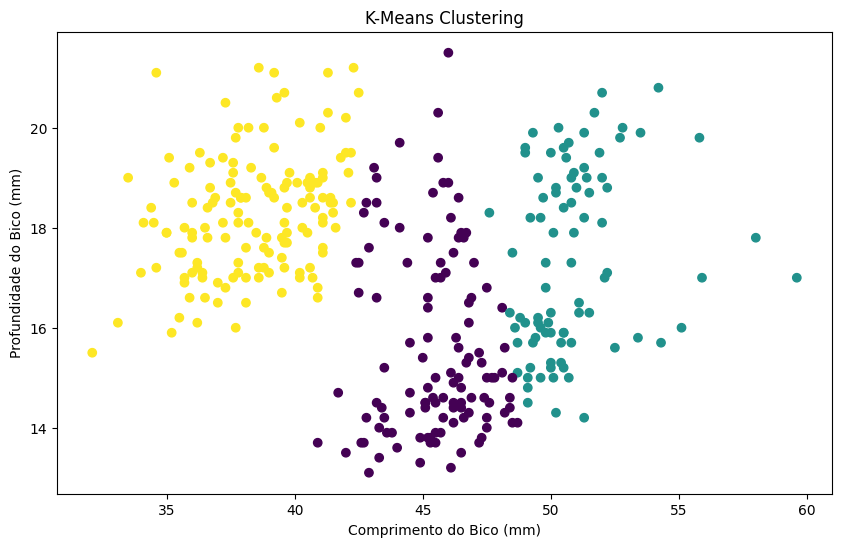

In [ ]:
# Visualizar os clusters
plt.figure(figsize=(10,6))
plt.scatter(X['bill_length_mm'], X['bill_depth_mm'], c=penguins.loc[X.index, 'cluster_kmeans'], cmap='viridis')
plt.xlabel('Comprimento do Bico (mm)')
plt.ylabel('Profundidade do Bico (mm)')
plt.title('K-Means Clustering')
plt.show()

### Exercícios

1. **Explique como o algoritmo K-Means determina os centros dos clusters.**

2. **Por que escolhemos k=3 para este conjunto de dados?**

3. **Observando o gráfico, os clusters formados correspondem às diferentes espécies de pinguins? Justifique sua resposta.**


## Exploração 2: DBSCAN

### O que é DBSCAN?

O DBSCAN (Density-Based Spatial Clustering of Applications with Noise) agrupa pontos que estão próximos uns dos outros com base em uma distância mínima e um número mínimo de pontos.


In [ ]:
# Importar as bibliotecas necessárias
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler


In [ ]:
# Padronizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Aplicar o algoritmo DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan.fit(X_scaled)

DBSCAN()

In [ ]:
# Adicionar os rótulos dos clusters aos dados
penguins['cluster_dbscan'] = pd.NA
penguins.loc[X.index, 'cluster_dbscan'] = dbscan.labels_

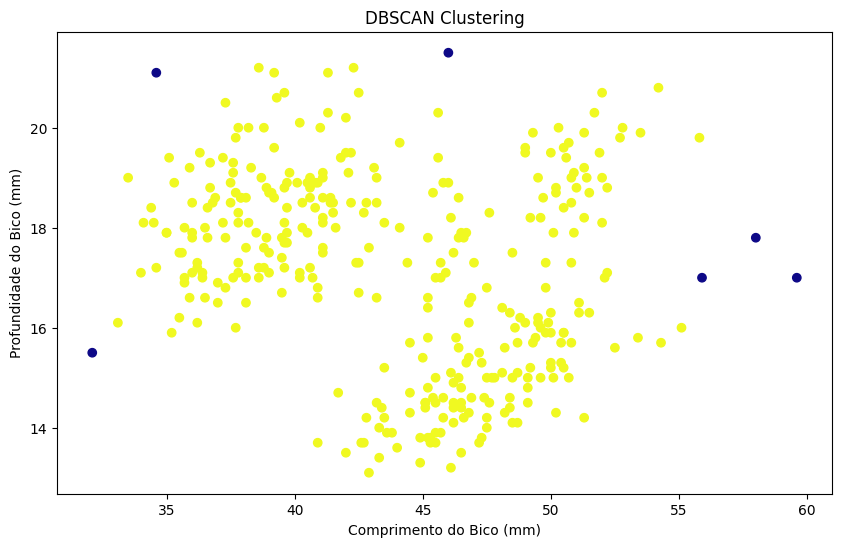

In [ ]:
# Visualizar os clusters
plt.figure(figsize=(10,6))
plt.scatter(X['bill_length_mm'], X['bill_depth_mm'], c=penguins.loc[X.index, 'cluster_dbscan'], cmap='plasma')
#plt.scatter(X['bill_length_mm'], X['bill_depth_mm'], c=penguins['cluster_dbscan'], cmap='plasma')
plt.xlabel('Comprimento do Bico (mm)')
plt.ylabel('Profundidade do Bico (mm)')
plt.title('DBSCAN Clustering')
plt.show()


### Exercícios

1. **O que significa um ponto ter o rótulo -1 no DBSCAN?**

2. **Como a padronização dos dados influencia o resultado do DBSCAN?**

3. **Experimente alterar os valores de `eps` e `min_samples`. Como isso afeta os clusters formados?**


## Exploração 3: Agrupamento Hierárquico

### O que é Agrupamento Hierárquico?

É um método que busca construir uma hierarquia de clusters, criando um dendrograma que mostra como os dados se unem.


In [ ]:
# Importar as bibliotecas necessárias
from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
# Aplicar o algoritmo de linkage
linked = linkage(X_scaled, method='ward')

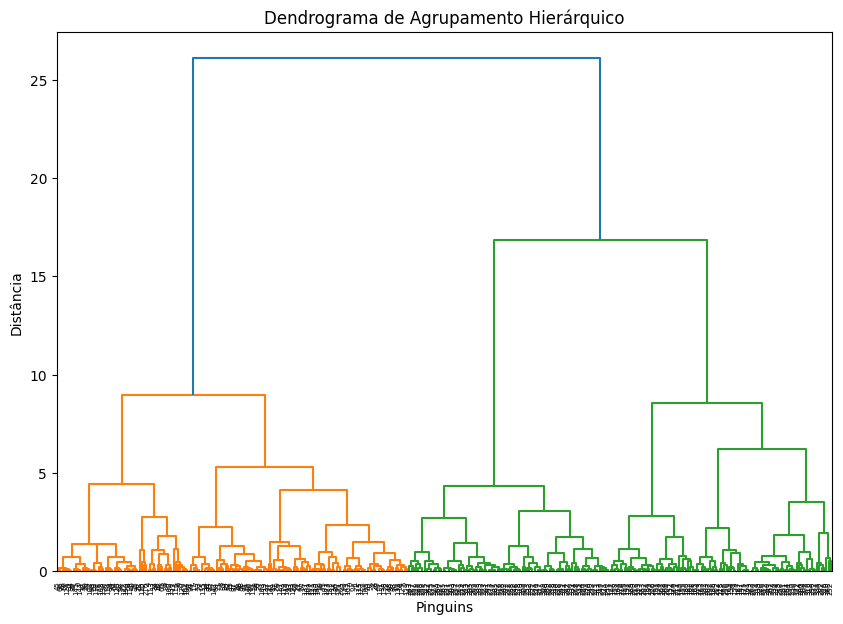

In [ ]:
# Plotar o dendrograma
plt.figure(figsize=(10, 7))
dendrogram(linked)
plt.title('Dendrograma de Agrupamento Hierárquico')
plt.xlabel('Pinguins')
plt.ylabel('Distância')
plt.show()


### Exercícios

1. **Explique o que representa cada eixo do dendrograma.**

2. **Com base no dendrograma, qual seria um número apropriado de clusters?**

3. **Como o método 'ward' utilizado na função `linkage` influencia a formação dos clusters?**


## Conclusão

Nesta aula, exploramos três métodos de clusterização diferentes utilizando a base de dados "penguins". Cada algoritmo tem suas características únicas e pode fornecer insights diferentes sobre os dados.

### Perguntas Finais

- **Qual algoritmo você achou mais adequado para separar as espécies de pinguins? Por quê?**

- **Como a escolha das características (variáveis) influencia nos resultados da clusterização?**

- **Quais outros atributos poderíamos usar para melhorar a separação entre as espécies?**
